In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")
pd.pandas.set_option("display.max_columns", None)

df = pd.read_csv(r"C:\Users\Sahil\OneDrive\Desktop\TY\USVisa\US-Visa\notebook\EasyVisa.csv")
print(df.shape)

(25480, 12)


In [4]:
features_with_na = [features for features in df.columns if df[features].isnull().sum()>=1]
for feature in features_with_na:
    print(feature , np.round(df[feature].isnull().mean()*100,5), '% missing values')

In [5]:
features_with_na

[]

In [6]:
df.duplicated().sum()

0

In [7]:
df.drop('case_id', inplace=True,axis=1)

In [8]:
df.head(5)

,continent,education_of_employee,has_job_experience,requires_job_training,no_of_employees,yr_of_estab,region_of_employment,prevailing_wage,unit_of_wage,full_time_position,case_status
0,Asia,High School,N,N,14513,2007,West,592.2029,Hour,Y,Denied
1,Asia,Master's,Y,N,2412,2002,Northeast,83425.6500,Year,Y,Certified
2,Asia,Bachelor's,N,Y,44444,2008,West,122996.8600,Year,Y,Denied
3,Asia,Bachelor's,N,N,98,1897,West,83434.0300,Year,Y,Denied
4,Africa,Master's,Y,N,1082,2005,South,149907.3900,Year,Y,Certified


In [9]:
from datetime import date

todays_date = date.today()
current_year = todays_date.year

In [10]:
current_year

2025

In [11]:
df['company_age'] = current_year - df['yr_of_estab']

In [12]:
df.head(5)

,continent,education_of_employee,has_job_experience,requires_job_training,no_of_employees,yr_of_estab,region_of_employment,prevailing_wage,unit_of_wage,full_time_position,case_status,company_age
0,Asia,High School,N,N,14513,2007,West,592.2029,Hour,Y,Denied,18
1,Asia,Master's,Y,N,2412,2002,Northeast,83425.6500,Year,Y,Certified,23
2,Asia,Bachelor's,N,Y,44444,2008,West,122996.8600,Year,Y,Denied,17
3,Asia,Bachelor's,N,N,98,1897,West,83434.0300,Year,Y,Denied,128
4,Africa,Master's,Y,N,1082,2005,South,149907.3900,Year,Y,Certified,20


In [13]:
df.drop('yr_of_estab', inplace=True,axis=1)

In [14]:
numeric_features = [feature for feature in df.columns if df[feature].dtype != 'O']
categorical_features = [feature for feature in df.columns if df[feature].dtype == 'O']
print('We have {} numerical features and {} categorical features'.format(len(numeric_features), len(categorical_features)))

We have 3 numerical features and 8 categorical features


In [15]:
discrete_features = [feature for feature in numeric_features if len(df[feature].unique()) <= 25]
continuous_features = [feature for feature in numeric_features if len(df[feature].unique()) > 25]

print('Discrete Features: ', discrete_features)
print('Continuous Features: ', continuous_features)

Discrete Features:  []
Continuous Features:  ['no_of_employees', 'prevailing_wage', 'company_age']


In [16]:
X = df.drop('case_status', axis=1)
y = df['case_status']

In [17]:
y.head()

0       Denied
1    Certified
2       Denied
3       Denied
4    Certified
Name: case_status, dtype: object

In [18]:
y = np.where(y=='Denied',1,0)

In [19]:
y

array([1, 0, 1, ..., 0, 0, 0])

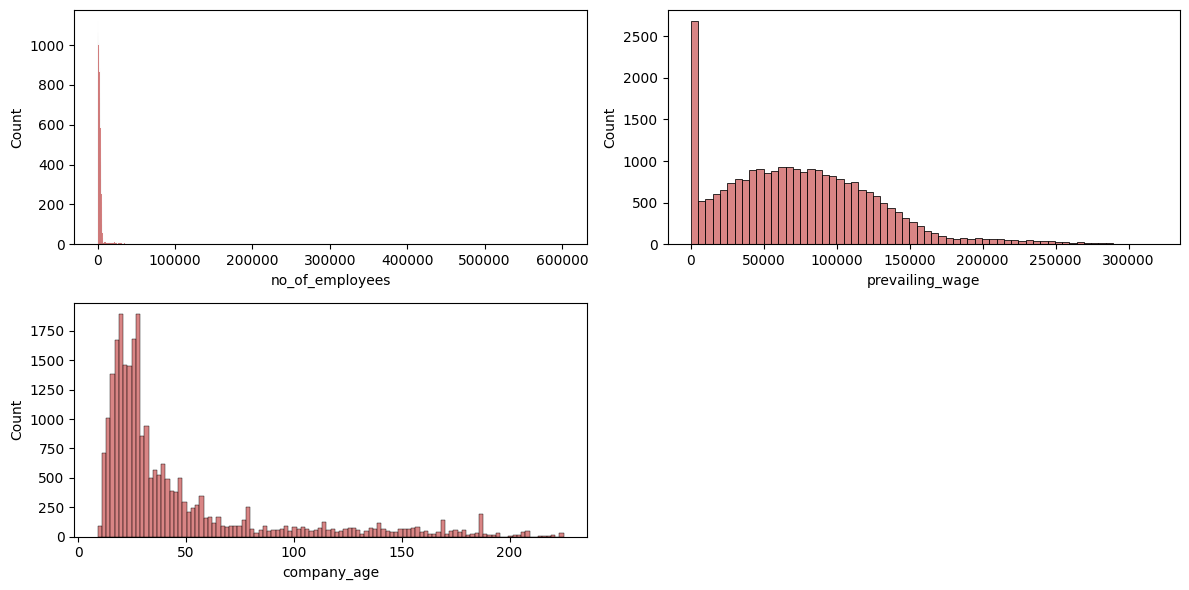

In [20]:
plt.figure(figsize=(12,6))
for i, col in enumerate(['no_of_employees','prevailing_wage','company_age']):
    plt.subplot(2,2,i+1)
    sns.histplot(x=X[col], color='indianred')
    plt.xlabel(col)
    plt.tight_layout()

- No of employees and Company age column is skewed
- Apply a power transform featurewise to make data more Gaussian like


In [21]:
X[continuous_features].skew(axis=0,skipna=True)

no_of_employees    12.265260
prevailing_wage     0.755776
company_age         2.037301
dtype: float64

- Positively Skewed : company_age , no_of_employees
- We can handle outliers and then check the skewness

### Apply Power Transformer to check if it can reduce the outliers

In [22]:
from sklearn.preprocessing import PowerTransformer
pt = PowerTransformer(method='yeo-johnson')
transform_features = ['company_age', 'no_of_employees']
X_copy = pt.fit_transform(X[transform_features])

In [23]:
X_copy = pd.DataFrame(X_copy, columns=transform_features)

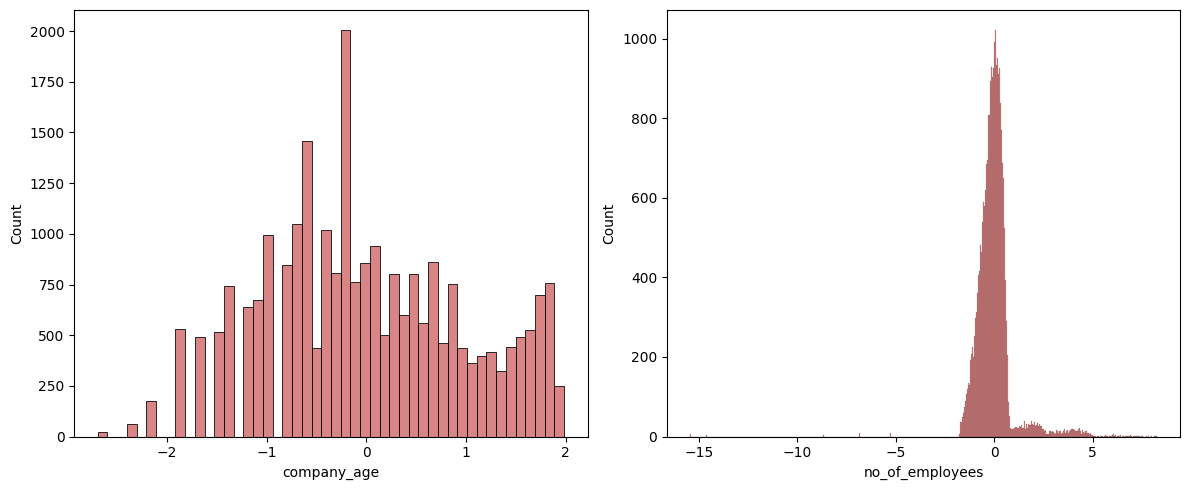

In [24]:
plt.figure(figsize=(12,5))
for i, col in enumerate(transform_features):
    plt.subplot(1,2,i+1)
    sns.histplot(x=X_copy[col], color='indianred')
    plt.xlabel(col)
    plt.tight_layout()

In [25]:
X_copy.skew(axis=0, skipna=True)

company_age        0.112260
no_of_employees    0.399339
dtype: float64

- Here Yeo-Johnson is used and it supports both positive or negative data for transformation
- So Power Transformer with yeo-johnson can be used

In [26]:
for feature in categorical_features:
    print(feature, ':', df[feature].nunique())

continent : 6
education_of_employee : 4
has_job_experience : 2
requires_job_training : 2
region_of_employment : 5
unit_of_wage : 4
full_time_position : 2
case_status : 2


In [27]:
num_features = list(X.select_dtypes(exclude="object").columns)
num_features

['no_of_employees', 'prevailing_wage', 'company_age']

In [28]:
# Create Column Transformer with 3 types of Transformers
or_columns = ['has_job_experience','requires_job_training','full_time_position','education_of_employee']
oh_columns = ['continent','unit_of_wage','region_of_employment']
transform_columns = ['no_of_employees','company_age']

from sklearn.preprocessing import OneHotEncoder, StandardScaler, OrdinalEncoder, PowerTransformer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

numeric_transformer = StandardScaler()
oh_transformer = OneHotEncoder(handle_unknown='ignore')
ordinal_encoder = OrdinalEncoder()

transform_pipe = Pipeline(steps=[
    ('power_transform', PowerTransformer(method='yeo-johnson'))
])

preprocessor = ColumnTransformer(
    [
        ("OneHotEncoder", oh_transformer, oh_columns),
        ("Ordinal_Encoder", ordinal_encoder, or_columns),
        ("Transformer", transform_pipe, transform_columns),
        ("StandardScaler", numeric_transformer, numeric_features)
    ]
)


In [29]:
X = preprocessor.fit_transform(X)


In [30]:
X

array([[ 0.        ,  1.        ,  0.        , ...,  0.38666657,
        -1.39853722, -0.65122993],
       [ 0.        ,  1.        ,  0.        , ..., -0.14228155,
         0.1698353 , -0.53321103],
       [ 0.        ,  1.        ,  0.        , ...,  1.69498375,
         0.91907852, -0.6748337 ],
       ...,
       [ 0.        ,  1.        ,  0.        , ..., -0.19871259,
         1.36027953,  1.63833662],
       [ 0.        ,  1.        ,  0.        , ..., -0.16387483,
         0.22150859,  2.18122353],
       [ 0.        ,  1.        ,  0.        , ..., -0.10805575,
        -0.06776315,  0.45814768]])

In [31]:
from imblearn.combine import SMOTETomek, SMOTEENN

smt = SMOTEENN(random_state=42,sampling_strategy='minority')
X_res, y_res = smt.fit_resample(X,y)

In [32]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X_res, y_res, test_size=0.2, random_state=42)
X_train.shape , X_test.shape

((13629, 24), (3408, 24))

In [38]:
from sklearn.ensemble import RandomForestClassifier , AdaBoostClassifier , GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, ConfusionMatrixDisplay, precision_score, recall_score , f1_score, roc_auc_score, roc_curve
from xgboost import XGBClassifier
from catboost import CatBoostClassifier

In [34]:
def evaluate_clf(true, predicted):
    acc = accuracy_score(true, predicted)
    f1 = f1_score(true,predicted)
    precision = precision_score(true,predicted)
    recall = recall_score(true, predicted)
    roc_auc = roc_auc_score(true, predicted)
    return acc, f1, precision, recall, roc_auc

In [35]:
models = {
    "Random Forest" : RandomForestClassifier(),
    "Decision Tree" : DecisionTreeClassifier(),
    "Gradient Boosting" : GradientBoostingClassifier(),
    "Logistic Regression" : LogisticRegression(),
    "K Neighbors Classifier" : KNeighborsClassifier(),
    "Cat Boosting Classifier" : CatBoostClassifier(),
    "Support Vector Classifier": SVC(),
    "AdaBoost Classifier" : AdaBoostClassifier()
    }

In [45]:
# Create a function which can evaluate models and return a report
def evaluate_models(X, y, models):
    X_train , X_test, y_train, y_test = train_test_split(X, y,test_size=0.2,random_state=42)

    models_list = []
    accuracy_list = []
    auc = []

    for i in range(len(list(models))):
        model = list(models.values())[i]
        model.fit(X_train, y_train)

        y_train_pred = model.predict(X_train)
        y_test_pred = model.predict(X_test)

        model_train_accuracy, model_train_f1, model_train_precision,model_train_recall,model_train_rocauc_score=evaluate_clf(y_train, y_train_pred)

        model_test_accuracy, model_test_f1, model_test_precision,model_test_recall,model_test_rocauc_score=evaluate_clf(y_test, y_test_pred)

        print(list(models.keys())[i])
        models_list.append(list(models.keys())[i])

        print("Model Performance for Training set")
        print(" - Accuracy: {:.4f}".format(model_train_accuracy))
        print(" - F1 score: {:.4f}".format(model_train_f1))
        print(" - Precision: {:.4f}".format(model_train_precision))
        print(" - Recall: {:.4f}".format(model_train_recall))
        print(" - Roc Auc Score:{:.4f}".format(model_test_rocauc_score))

        print('---------------------------------------------------')

        print("Model Performance for test set")
        print(' - Accuracy: {:.4f}'.format(model_test_accuracy))
        accuracy_list.append(model_test_accuracy)
        print(' - F1 Score: {:.4f}'.format(model_test_f1))
        print(' - Precision: {:.4f}'.format(model_test_precision))
        print(' - Recall: {:.4f}'.format(model_test_recall))
        print(' - Roc Auc Score: {:.4f}'.format(model_test_rocauc_score))
        auc.append(model_test_rocauc_score)
        print('='*35)
        print('\n')

    report = pd.DataFrame(list(zip(models_list, accuracy_list)), columns=['Model Name', 'Accuracy']).sort_values(by="Accuracy", ascending=False)

    return report


        



In [46]:
base_model_report = evaluate_models(X=X_res, y=y_res, models = models)

Random Forest
Model Performance for Training set
 - Accuracy: 1.0000
 - F1 score: 1.0000
 - Precision: 1.0000
 - Recall: 1.0000
 - Roc Auc Score:0.9511
---------------------------------------------------
Model Performance for test set
 - Accuracy: 0.9519
 - F1 Score: 0.9557
 - Precision: 0.9501
 - Recall: 0.9614
 - Roc Auc Score: 0.9511


Decision Tree
Model Performance for Training set
 - Accuracy: 1.0000
 - F1 score: 1.0000
 - Precision: 1.0000
 - Recall: 1.0000
 - Roc Auc Score:0.9247
---------------------------------------------------
Model Performance for test set
 - Accuracy: 0.9258
 - F1 Score: 0.9318
 - Precision: 0.9250
 - Recall: 0.9386
 - Roc Auc Score: 0.9247


Gradient Boosting
Model Performance for Training set
 - Accuracy: 0.8897
 - F1 score: 0.8965
 - Precision: 0.9068
 - Recall: 0.8865
 - Roc Auc Score:0.8788
---------------------------------------------------
Model Performance for test set
 - Accuracy: 0.8791
 - F1 Score: 0.8875
 - Precision: 0.8919
 - Recall: 0.8832


In [47]:
base_model_report

,Model Name,Accuracy
0,Random Forest,0.951878
4,K Neighbors Classifier,0.941608
5,Cat Boosting Classifier,0.926056
1,Decision Tree,0.925763
2,Gradient Boosting,0.879108
6,Support Vector Classifier,0.857101
7,AdaBoost Classifier,0.849178
3,Logistic Regression,0.725646


#### Here we can use Random Forest for Hyper Parameter Tuning
#### Define the parameter distribution for Random Forest

In [49]:
#Initialize few parameter for Hyperparameter tuning
xgboost_params = {
    'max_depth':range(3,10,2),
    'min_child_weight':range(1,6,2)
}

rf_params = {
    'max_depth' : [10,12,None,15,20],
    'max_features':['sqrt','log2','None'],
    'n_estimators':[10,50,100,200]
}

knn_params = {
    'algorithm' : ['auto','ball_tree','kd_tree','brute'],
    'weights' : ['uniform','distance'],
    'n_neighbors' : [3,4,5,7,9]
}

In [50]:
randomcv_models = [
    ('XGBoost' , XGBClassifier(), xgboost_params),
    ('RF', RandomForestClassifier(), rf_params),
    ('KNN', KNeighborsClassifier(), knn_params)
]

#### Create a function for model training and report which can be used in hyperparameter tuning loop

In [52]:
from sklearn.model_selection import RandomizedSearchCV

model_param = {}
for name, model, params in randomcv_models:
    random = RandomizedSearchCV(estimator=model,
                                param_distributions=params,
                                n_iter=100,
                                cv=3,
                                verbose=2,
                                n_jobs=-1)
    
    random.fit(X_res, y_res)
    model_param[name] = random.best_params_

for model_name in model_param:
    print(f"----------------------Best Params for {model_name}-------------------------")
    print(model_param[model_name])

Fitting 3 folds for each of 12 candidates, totalling 36 fits
Fitting 3 folds for each of 60 candidates, totalling 180 fits
Fitting 3 folds for each of 40 candidates, totalling 120 fits
----------------------Best Params for XGBoost-------------------------
{'min_child_weight': 1, 'max_depth': 9}
----------------------Best Params for RF-------------------------
{'n_estimators': 200, 'max_features': 'sqrt', 'max_depth': None}
----------------------Best Params for KNN-------------------------
{'weights': 'distance', 'n_neighbors': 4, 'algorithm': 'auto'}


In [53]:
from sklearn.metrics import roc_auc_score, roc_curve
best_models = {
    "RandomForestClassifier":RandomForestClassifier(**model_param['RF']),
    "KNeighborsClassifier" : KNeighborsClassifier(**model_param['KNN']),
    "XGBClassifier" : XGBClassifier(**model_param['XGBoost'], n_jobs=-1)
}
tuned_report = evaluate_models(X=X_res, y=y_res, models=best_models)

RandomForestClassifier
Model Performance for Training set
 - Accuracy: 1.0000
 - F1 score: 1.0000
 - Precision: 1.0000
 - Recall: 1.0000
 - Roc Auc Score:0.9491
---------------------------------------------------
Model Performance for test set
 - Accuracy: 0.9501
 - F1 Score: 0.9542
 - Precision: 0.9470
 - Recall: 0.9614
 - Roc Auc Score: 0.9491


KNeighborsClassifier
Model Performance for Training set
 - Accuracy: 1.0000
 - F1 score: 1.0000
 - Precision: 1.0000
 - Recall: 1.0000
 - Roc Auc Score:0.9669
---------------------------------------------------
Model Performance for test set
 - Accuracy: 0.9683
 - F1 Score: 0.9711
 - Precision: 0.9577
 - Recall: 0.9848
 - Roc Auc Score: 0.9669


XGBClassifier
Model Performance for Training set
 - Accuracy: 0.9993
 - F1 score: 0.9993
 - Precision: 0.9986
 - Recall: 1.0000
 - Roc Auc Score:0.9452
---------------------------------------------------
Model Performance for test set
 - Accuracy: 0.9457
 - F1 Score: 0.9499
 - Precision: 0.9475
 - Rec

In [54]:
tuned_report

,Model Name,Accuracy
1,KNeighborsClassifier,0.968310
0,RandomForestClassifier,0.950117
2,XGBClassifier,0.945716


In [55]:
best_model = KNeighborsClassifier(**model_param['KNN'])
best_model = best_model.fit(X_train,y_train)
y_pred = best_model.predict(X_test)
score = accuracy_score(y_test,y_pred)
cr = classification_report(y_test,y_pred)

print("FINAL MODEL KNN")
print("Accuracy Score Value: {:.4f}".format(score))
print(cr)

FINAL MODEL KNN
Accuracy Score Value: 0.9683
              precision    recall  f1-score   support

           0       0.98      0.95      0.96      1568
           1       0.96      0.98      0.97      1840

    accuracy                           0.97      3408
   macro avg       0.97      0.97      0.97      3408
weighted avg       0.97      0.97      0.97      3408



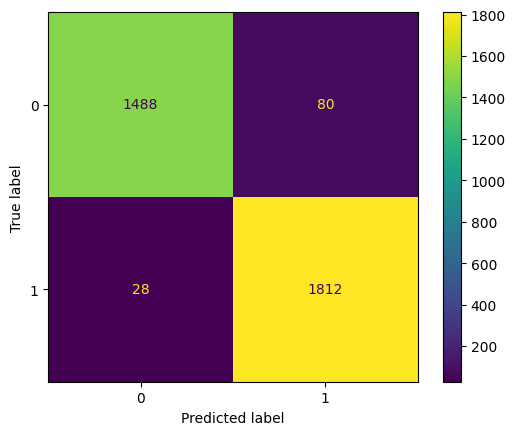

In [56]:
from sklearn.metrics import ConfusionMatrixDisplay
ConfusionMatrixDisplay.from_estimator(best_model, X_test, y_test)

## Best Model is K-Nearest Neighbor(KNN) with Accuracy of 96.83%